# **Лабораторна робота №1**

## **Тема: Наближене розв’язування нелінійних рівнянь**

_Мета: ознайомлення студентів з основними поняттями та алгоритмами
відокремлення та уточнення коренів нелінійних рівнянь; набуття
практичних навичок розв’язання таких задач з використанням комп’ютера._

Виконали:
1. Андрусик Вікторія
2. Лісовий Максим
3. Михайлюк Віталій
4. Оленич Максим

Лідер команди: Андрусик Вікторія

### Завдання:

1. Опрацювати теоретичний матеріал.

2. Відокремити дійсні корені заданих нелінійних рівнянь відповідно до
варіанту своєї команди: для алгебраїчного рівняння – поєднанням трьох
методів:

     аналітичним (встановити наявність дійсних коренів; з’ясувати
    кількість додатних та від’ємних дійсних коренів; встановити кільце, в
    якому знаходяться усі корені рівняння);

     табличним (уточнити інтервали ізоляції дійсних коренів);

     графічним;

    Для трансцендентного рівняння – лише графічним і табличним.

3. Уточнити по одному з дійсних коренів заданих рівнянь з точністю до
  0,001 чотирма методами :

     методом дихотомії (половинного ділення);

     методом хорд;

     методом Ньютона (дотичних);

     методом простої ітерації.

4. Скласти зведену порівняльну таблицю


In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize
import math

In [34]:
alg_func = lambda x: x ** 4 - 2 * (x ** 3) + x - 1.5

trans_func = lambda x: math.sin(x) - x + 0.25

In [35]:
def half(a, b, epsilon, func):
    iters = 0
    while abs(b - a) >= 2 * epsilon:
        c = (a + b) / 2
        f_c = func(c)
        f_a = func(a)
        iters += 1

        if f_c == 0:
            return c, iters

        if f_a * f_c < 0:
            b = c
        else:
            a = c

    return (a + b) / 2, iters

In [36]:
def Phurie(a, b, func):
    mid = (a + b) / 2.0
    h = 1e-5
    f2_val = (func(mid + h) - 2 * func(mid) + func(mid - h)) / (h ** 2)

    if func(a) * f2_val > 0:
        fixed_point = a
        x_curr = b
    else:
        fixed_point = b
        x_curr = a

    return fixed_point, x_curr, func(fixed_point)

In [37]:
def horda_auto(a, b, epsilon, func):
    fixed_point, x_curr, f_fixed = Phurie(a, b, func)
    iters = 0
    while True:
        iters += 1
        f_curr = func(x_curr)
        x_next = x_curr - (f_curr * (fixed_point - x_curr)) / (f_fixed - f_curr)

        if abs(x_next - x_curr) < epsilon or abs(func(x_next)) < epsilon:
            return x_next, iters

        x_curr = x_next

In [38]:
def Newton(a, b, epsilon, func, dfunc=None):
    x_curr, _, _ = Phurie(a, b, func)
    h = 1e-6
    if dfunc is None:
        dfunc = lambda x: (func(x + h) - func(x)) / h

    iters = 0
    while True:
        iters += 1
        f_val = func(x_curr)
        df_val = dfunc(x_curr)

        if df_val == 0:
            raise ZeroDivisionError("Похідна дорівнює нулю. Метод дотичних не застосовний.")

        x_next = x_curr - f_val / df_val

        if abs(x_next - x_curr) < epsilon or abs(func(x_next)) < epsilon:
            return x_next, iters

        x_curr = x_next

In [39]:
def iteration(a, b, epsilon, func, dfunc=None, max_iter = 1000):
    h = 1e-6
    if dfunc is None:
        dfunc = lambda x: (func(x + h) - func(x)) / h

    xs = np.linspace(a, b, 100)
    df_vals = [dfunc(x) for x in xs]

    min_df = min(df_vals)
    max_df = max(df_vals)

    if min_df * max_df <= 0:
        raise ValueError("Похідна змінює знак на проміжку — звузьте інтервал [a,b]")

    sign = 1 if min_df > 0 else -1
    m = min(abs(min_df), abs(max_df))
    M = max(abs(min_df), abs(max_df))

    lam = sign * (2.0 / (M + m))
    phi = lambda x: x - lam * func(x)

    x_curr = (a + b) / 2.0
    for iters in range(1, max_iter + 1):
        x_next = phi(x_curr)

        if abs(x_next - x_curr) < epsilon or abs(func(x_next)) < epsilon:
            return x_next, iters

        x_curr = x_next

    raise RuntimeError("Не вдалося зійтися за максимальну кількість ітерацій.")

In [40]:
def f1(x: float) -> float:
    return x**4 - 2*x**3 + x - 1.5

def f2(x: float) -> float:
    return np.sin(x) - x + 0.25

def tabulate_function(f: callable, a: float, b: float, h: float = 1) -> dict:
    """
    Починаючи з точки a, обчислюємо значення функції f(x) через крок h до точки b.
    Результати зберігаються у словнику, де ключами є значення x,
    а значеннями - відповідні значення функції f(x).
    """
    tabulated_function = {}
    x = a

    num_steps = int(round((b - a) / h)) + 1

    for i in range(num_steps):
        x = round(a + i * h, 10)
        tabulated_function[x] = f(x)

    return tabulated_function

def table_method(f: callable, a: float, b: float, h1: float = 1.0) -> list:
    """
    Табулюємо функцію з великим кроком h1.
    Знаходимо всі інтервали зміни знака (ширші діапазони). Для кожного
    знайденого інтервалу запускаємо табуляцію з меншим кроком h2 = h1 / 2 і
    повертаємо вужчі інтервали.
    """
    intervals = []
    smaller_intervals = []

    tabulated_function = tabulate_function(f, a, b, h1)
    items = list(tabulated_function.items())

    for i in range(len(items) - 1):
        x1, y1 = items[i]
        x2, y2 = items[i + 1]
        if y1 * y2 < 0:
            intervals.append((x1, x2))
    # Прибери в коментарі, якщо не хочеш бачити ширші діапазони
    # print("Ширші діапазони:", intervals)

    h2 = h1 / 2
    for x, y in intervals:
        tabulated_function = tabulate_function(f, x, y, h2)
        items = list(tabulated_function.items())

        for i in range(len(items) - 1):
            x1, y1 = items[i]
            x2, y2 = items[i + 1]
            if y1 * y2 < 0:
                smaller_intervals.append((x1, x2))
    # Прибери в коментарі, якщо не хочеш бачити вужчі діапазони
    # print("Вужчі діапазони:", smaller_intervals)

    return smaller_intervals

# coefs = коефіцієнти многочлена починаючи з старшого степеня до вільного члена
def analytical_method(coefs: list) -> dict:
    """
    Основна теорема алгебри: у нас є n коренів де n - найвищий степінь многочлена
    Наслідок від неї: рівняння непарного степеня має хоча б один корінь
    Теорема Декарта: n додатних коренів = число змін знаків коефіцієнтів
    Теорема Гюа: якщо всі корені дійсні, тоді квадрат будь-якого коефіцієнта(крім крайніх) більший за
    Теорема про кільце коренів: корені многочлена містяться в кільці(рядок 110).
    """
    # Основна теорема алгебри
    n = len(coefs) - 1

    a_n = coefs[0]
    a0 = coefs[-1]

    # Наслідок з основної теореми алгебри
    has_real_guaranteed = n % 2 != 0

    # Теорема Декарта: додатні корені
    non_zero_pos = [c for c in coefs if c != 0]
    pos_roots_changes = 0
    for i in range(len(non_zero_pos) - 1):
        if non_zero_pos[i] * non_zero_pos[i + 1] < 0:
            pos_roots_changes += 1

    # Теорема Декарта: від'ємні корені
    neg_coefs = [(-c if (n - i) % 2 != 0 else c) for i, c in enumerate(coefs)]
    non_zero_neg = [c for c in neg_coefs if c != 0]
    neg_roots_changes = 0
    for i in range(len(non_zero_neg) - 1):
        if non_zero_neg[i] * non_zero_neg[i + 1] < 0:
            neg_roots_changes += 1

    # Теорема Гюа
    all_roots_real = True
    for k in range(1, n):
        if coefs[k] ** 2 <= coefs[k - 1] * coefs[k + 1]:
            all_roots_real = False
            break

    # Кільце коренів
    a = max(abs(x) for x in coefs[1:])
    b = max(abs(x) for x in coefs[:-1])

    lower_bound = abs(a0) / (abs(a0) + b)
    upper_bound = 1 + a / abs(a_n)
    ring = (round(lower_bound, 4), round(upper_bound, 4))

    return {
        "total_roots": n,
        "has_real_guaranteed": has_real_guaranteed,
        "pos_roots_max": pos_roots_changes,
        "neg_roots_max": neg_roots_changes,
        "all_roots_real_necessary": all_roots_real,
        "ring": ring,
    }

def f1_left(x):
    return 8 * x**4 - 8 * x**2

def f1_right(x):
    return -32 * x - 1

def f2_left(x):
    return 2 - x

def f2_right(x):
    return np.log10(x)

"""
g1, g2 - елементарні функції які легше зобразити на графіку,
такі щоб f(x) = g1(x) - g2(x)
"""
def graphic_method(
    g1: callable, g2: callable, a: float, b: float, h: float = 0.01
) -> list[float]:
    """
    Приблизний розв'язок - середина діапазону
    де різниця значень двох функцій
    на кінцях має різний знак,
    для кращої точності задаємо малий крок h
    """
    x_vals = np.arange(a, b + h / 2, h)
    diff = g1(x_vals) - g2(x_vals)

    roots = []
    for i in range(len(diff) - 1):
        if diff[i] * diff[i + 1] <= 0:
            x_approx = round((x_vals[i] + x_vals[i + 1]) / 2, 2)
            roots.append(x_approx)

    for i in range(len(roots)):
        roots[i] = float(roots[i])

    return roots

def plot_graphical_separation(
    g1: callable,
    g2: callable,
    a: float,
    b: float,
    title: str = "",
    g1_label: str = "y1",
    g2_label: str = "y2",
):

    roots = graphic_method(g1, g2, a, b)

    x_vals = np.linspace(a, b, 500)
    plt.figure(figsize=(7, 4.5))
    plt.plot(x_vals, g1(x_vals), label=g1_label, color="tab:blue", lw=2)
    plt.plot(
        x_vals,
        g2(x_vals),
        label=g2_label,
        color="tab:red",
        linestyle="--",
        lw=2,
    )

    for r in roots:
        y_val = g1(r)
        plt.scatter([r], [y_val], color="green", s=50, zorder=5)
        plt.annotate(
            f"x ≈ {r}",
            (r, y_val),
            textcoords="offset points",
            xytext=(0, 10),
            ha="center",
            fontweight="bold",
        )

    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return roots

In [41]:
eps = 0.001
a = (-1, 1.5)
b = (-0.5, 2.0)
x0 = -0.75

df = lambda x: 4*(x**3) - 6*(x**2) + 1

# 1 Метод дихотомії - SciPy
root_bisect = optimize.bisect(alg_func, a=a[0], b=b[0], xtol=eps)
root_bisect2 = optimize.bisect(alg_func, a=a[1], b=b[1], xtol=eps)

# 2 Метод хорд - SciPy
root_secant = optimize.root_scalar(alg_func, x0=a[0], x1=b[0], method='secant', xtol=eps).root
root_secant2 = optimize.root_scalar(alg_func, x0=a[1], x1=b[1], method='secant', xtol=eps).root

# 3 Метод Ньютона - SciPy
root_newton = optimize.newton(alg_func, x0=x0, fprime=df, tol=eps)

# 4 Пошук коренів полінома - NumPy
coeffs = [1, -2, 0, 1, -1.5]
poly_roots = np.roots(coeffs)
root_numpy = float([r.real for r in poly_roots if np.isreal(r) and a[0] <= r.real <= b[0]][0])
root_numpy1 = float([r.real for r in poly_roots if np.isreal(r) and a[1] <= r.real <= b[1]][0])

In [42]:
df_alg = lambda x: 4*(x**3) - 6*(x**2) + 1
df_trans = lambda x: math.cos(x) - 1

def print_result_table(title, a, b, eps, func, dfunc=None):
    res_half = half(a, b, eps, func)
    res_horda = horda_auto(a, b, eps, func)
    res_newton = Newton(a, b, eps, func, dfunc)
    res_iter = iteration(a, b, eps, func, dfunc)

    print(f"\n{title} (Інтервал [{a}, {b}])")
    print("-" * 88)
    print(f"| {'№':<2} | {'Метод':<32} | {'Отримане значення x* ≈':<22} | {'Кількість ітерацій':<18} |")
    print("-" * 88)
    print(f"| 1  | {'Дихотомії (половинного ділення)':<32} | {res_half[0]:<22.6f} | {res_half[1]:<18} |")
    print(f"| 2  | {'Хорд':<32} | {res_horda[0]:<22.6f} | {res_horda[1]:<18} |")
    print(f"| 3  | {'Ньютона (дотичних)':<32} | {res_newton[0]:<22.6f} | {res_newton[1]:<18} |")
    print(f"| 4  | {'Простої ітерації':<32} | {res_iter[0]:<22.6f} | {res_iter[1]:<18} |")
    print("-" * 88)

Завдання 1: 
---------------------------------------------------------------------------------------


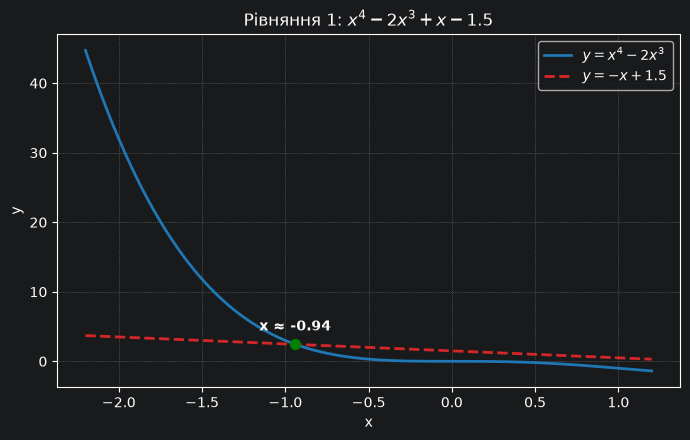

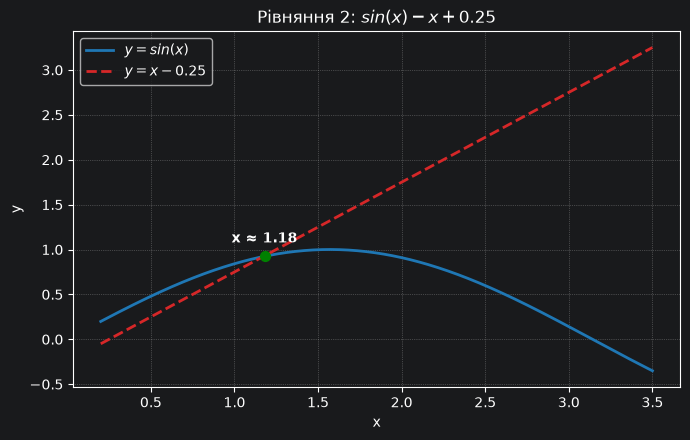

Табличні інтервали f1(x): [(-1.0, -0.5), (1.5, 2.0)]
Аналітичний висновок f1(x):
 Кількість коренів: 4 
 Гарантовано дійсний корінь: False 
 Максимальна кількість додатних коренів: 3 
 Максимальна кількість від'ємних коренів: 1 
 Необхідність наявності дійсності коренів: True 
 Кільце з усіма коренями: (0.4286, 3.0)
Знайдені корені для f1(x) графічно: [-0.94]
-----------------------------------
Табличні інтервали f2(x): [(1.0, 1.5)]
Знайдені корені для f2 графічно: [1.18]
---------------------------------------------------------------------------------------
Завдання 2: 
---------------------------------------------------------------------------------------
1. Метод дихотомії SciPy:  -0.9404
2. Метод хорд SciPy:       -0.9398
3. Метод Ньютона SciPy:    -0.9397
4. Метод поліномів NumPy:  1.9397
---------------------------------------------------------------------------------------
Завдання 3: 
---------------------------------------------------------------------------------------
1. Мет

In [43]:
a = 1
b = 1.5
eps = 0.001
print("Завдання 1: ")
print("---------------------------------------------------------------------------------------")
roots_f1 = plot_graphical_separation(
    g1=lambda x: x**4 - 2*x**3,
    g2=lambda x: -x + 1.5,
    a=-2.2,
    b=1.2,
    title=r"Рівняння 1: $x^4 - 2x^3 + x - 1.5$",
    g1_label=r"$y = x^4 - 2x^3$",
    g2_label=r"$y = -x + 1.5$",
)

roots_f2 = plot_graphical_separation(
    g1=lambda x: np.sin(x),
    g2=lambda x: x - 0.25,
    a=0.2,
    b=3.5,
    title=r"Рівняння 2: $sin(x) - x + 0.25$",
    g1_label=r"$y = sin(x)$",
    g2_label=r"$y = x - 0.25$",
)

print("Табличні інтервали f1(x):", table_method(f1, a=-10, b = 10))
f1_analytical = analytical_method([1, -2, 0, 1, -1.5])
print("Аналітичний висновок f1(x):\n",
      "Кількість коренів:", f1_analytical["total_roots"], "\n",
      "Гарантовано дійсний корінь:", f1_analytical["has_real_guaranteed"], "\n",
      "Максимальна кількість додатних коренів:", f1_analytical["pos_roots_max"], "\n",
      "Максимальна кількість від'ємних коренів:", f1_analytical["neg_roots_max"], "\n",
      "Необхідність наявності дійсності коренів:", f1_analytical["all_roots_real_necessary"], "\n",
      "Кільце з усіма коренями:", f1_analytical["ring"]
      )
print("Знайдені корені для f1(x) графічно:", roots_f1)
print("-----------------------------------")
print("Табличні інтервали f2(x):", table_method(f2, a=0.5, b=4.0, h1=1.0))
print("Знайдені корені для f2 графічно:", roots_f2)
print("---------------------------------------------------------------------------------------")

print("Завдання 2: ")
print("---------------------------------------------------------------------------------------")
print(f"1. Метод дихотомії SciPy:  {root_bisect:.4f}")
print(f"2. Метод хорд SciPy:       {root_secant:.4f}")
print(f"3. Метод Ньютона SciPy:    {root_newton:.4f}")
print(f"4. Метод поліномів NumPy:  {root_numpy1:.4f}")
print("---------------------------------------------------------------------------------------")


print("Завдання 3: ")
print("---------------------------------------------------------------------------------------")
print(f"1. Метод дихотомії:  {half(a, b, eps, trans_func)}")
print(f"2. Метод хорд:       {horda_auto(a, b, eps, trans_func)}")
print(f"3. Метод Ньютона:    {Newton(a, b, eps, trans_func)}")
print(f"4. Метод поліномів:  {iteration(a, b, eps, trans_func)}")
print("---------------------------------------------------------------------------------------")


print("Завдання 4: ")
print("---------------------------------------------------------------------------------------")
print_result_table("Алгебраїчне рівняння: Корінь 1", -1.0, -0.5, eps, alg_func, df_alg)
print_result_table("Алгебраїчне рівняння: Корінь 2", 1.5, 2.0, eps, alg_func, df_alg)
print_result_table("Трансцендентне рівняння", 1.0, 1.5, eps, trans_func, df_trans)
